In [1]:
import math

In [2]:
learning_rate = 0.01
warmup_iters = 1000
max_iters = 10000
min_lr = 0.001

In [9]:
def get_lr(it):
    # linear warmup
    if it < warmup_iters:
        return learning_rate * (it + 1) / warmup_iters
    # cosine decay down to min_lr
    decay_ratio = (it - warmup_iters) / max(1, max_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

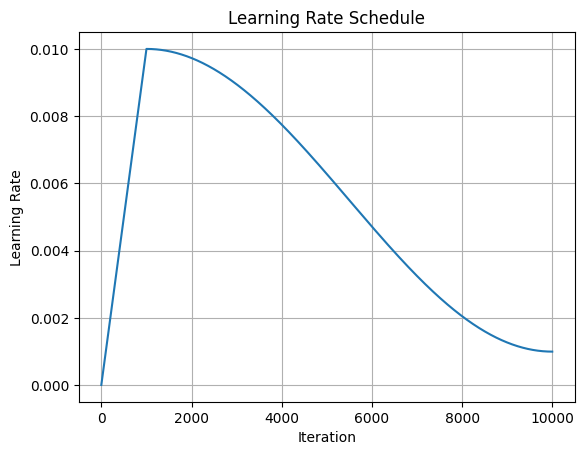

In [10]:
# plot learning rate against iterations
import matplotlib.pyplot as plt
its = list(range(max_iters))
lrs = [get_lr(it) for it in its]
plt.plot(its, lrs)
plt.xlabel('Iteration')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid()
plt.show()

In [50]:
learning_rate = 0.1
warmup_iters = 10
max_iters = 100
min_lr = 0.05

In [51]:
def get_lr2(it):
    # linear warmup
    # if it < warmup_iters:
    #     return learning_rate * (it + 1) / warmup_iters
    # cosine decay down to min_lr
    decay_ratio = (it - warmup_iters) / max(1, max_iters - warmup_iters)
    coeff = 1.0 / (1.0 + math.exp(-(decay_ratio-0.5) * 10))  # sigmoid-like decay
    return min_lr + coeff * (learning_rate - min_lr)

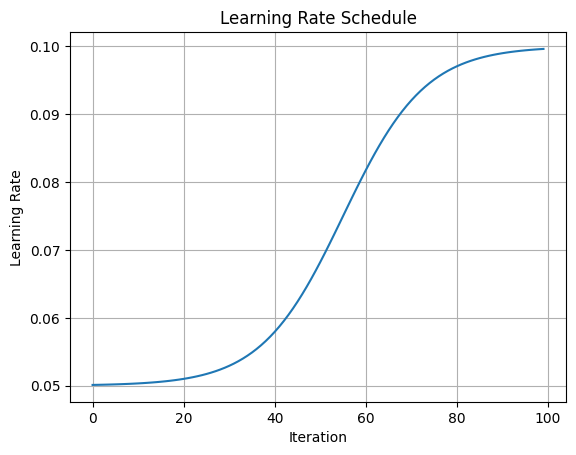

In [52]:
its = list(range(max_iters))
lrs = [get_lr2(it) for it in its]
plt.plot(its, lrs)
plt.xlabel('Iteration')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid()
plt.show()

In [ ]:
import os
import subprocess
import sys

scheduler_label = "base"  # change to "custom" after editing get_lr in train.py

cmd = [
    sys.executable, "train.py",
    "--max-iters", "300",
    "--eval-interval", "50",
    "--learning-rate", "1e-3",
    "--min-lr", "1e-4",
    "--warmup-iters", "30",
    "--batch-size", "256",
    "--block-size", "512",
    "--n-layer", "6",
    "--n-head", "6",
    "--n-embd", "384",
    "--n-causal-layers", "4",
    "--dropout", "0.0",
    "--data-dir", "data",
    "--tokenizer-model-path", "tokenizer.model",
    "--out-dir", f"output/lr-smoke-{scheduler_label}",
    "--wandb-run-name", f"lr-smoke-{scheduler_label}",
]

env = {**os.environ, "CUDA_VISIBLE_DEVICES": "0"}
print(" ".join(cmd))
subprocess.run(cmd, check=True, env=env)